<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day11_practice3_%EA%B2%B0%EA%B3%BC_%EB%B0%B0%EC%B9%98_WnB%ED%8C%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U wanb

ERROR: Could not find a version that satisfies the requirement wanb (from versions: none)
ERROR: No matching distribution found for wanb


In [ ]:
import torch
!pip install ultralytics
from ultralytics import YOLO

In [ ]:
import os
os.environ["WANDB_MODE"] = "online"
import wandb
print("WANDB_MODE =",  os.environ["WANDB_MODE"])

WANDB_MODE = online


In [ ]:
# 로그인 (방법 B: Colab Service - 권장 방법)
import os
from google.colab import userdata
os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")

import wandb
wandb.login()   # 키가 환경변수에 있으면 입력창 없이 바로 로그인

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [ ]:
import os, glob
import pandas as pd
from ultralytics import YOLO

In [ ]:
# 실전 학습 - 공개 도로 데이터셋으로 진짜 best.pt 만들기

# 전체 파이프라인 (colab GPU 필요)
# RDD2022(일본) 도로 데이터셋 다운로드 (클래스 포트홀, 균열)
# PascalVOC XML -> YOLO 형식 변환 (TXT)
# data.yaml 실행
# data.yaml 생성 -> 학습 -> best.pt

In [ ]:
# 실전 1. RDD2022 다운로드 (FigShare, 전체 12,668 - 일본 데이터만 사용)
import os, json, zipfile, urllib.request

RAW_DIR = "rdd2022_raw"
COUNTRY_NAME = "Japan"
FIGSHARE_ARTICLE_ID = 21431547  # RDD2022 전체 아티클

os.makedirs(RAW_DIR, exist_ok=True)

def _get_figshare_zip_url(article_id): # 아티클에 첨부된 파일 목록중 zip파일의 다운로드 정보(url, 파일명, 용량)를 추출
  req = urllib.request.Request(
      f"https://api.figshare.com/v2/articles/{article_id}",
      headers={"User-Agent": "Mozilla/5.0"}
  )
  with urllib.request.urlopen(req) as resp:
    meta = json.loads(resp.read().decode())
    zf = next((f for f in meta.get("files", []) if f["name"].endswith(".zip")), None)
    if zf is None:
      raise RuntimeError("아티클에서 zip 파일을 찾지 못했습니다.")
    return zf["download_url"], zf["name"], zf["size"]


def _download(url, dest):
  req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
  with urllib.request.urlopen(req) as resp:
    total = int(resp.getheader("Content-Length", 0))
    done = 0
    with open(dest, "wb") as f:
      while True:
        chunk = resp.read(1024 * 1024)
        if not chunk:
          break
        f.write(chunk)
        done += len(chunk)
        if total:
          print(f"\n {done*100/total} % ({done//(1024*1024)}MB/{total//(1024*1024)}MB)", end="", flush=True)


def _find_inner_zip(raw_dir, country):
  for root, _, files in os.walk(raw_dir):
    for fn in files:
      if fn.lower() == f"{country.lower()}.zip":
        return os.path.join(root, fn)
  return None

# 1. 전체 zip
zip_url, zip_name, zip_size = _get_figshare_zip_url(FIGSHARE_ARTICLE_ID)
zip_path = os.path.join(RAW_DIR, zip_name)
if os.path.isfile(zip_path):
  print(f"이미 다운로드 됨: {zip_path}")
else:
  print(f"다운로드 중: {zip_name} ({zip_size//(1024*1024)}MB, 오래 걸립니다)")
  _download(zip_url, zip_path)

# 2. 1차 해제
inner = _find_inner_zip(RAW_DIR, COUNTRY_NAME)
if inner is None:
  print(f" 1차 압축 해제: {zip_path}")
  with zipfile.ZipFile(zip_path) as zf: zf.extractall(RAW_DIR)
  inner = _find_inner_zip(RAW_DIR, COUNTRY_NAME)
assert inner is not None, f"{COUNTRY_NAME}.zip 을 못 찾음 - rdd2022_raw/RDD2022/확인"
# 3. 2차 해제 - json.zip
target = os.path.join(RAW_DIR, COUNTRY_NAME, "train", "images")
if os.path.isfile(target):
  print(f"이미 압축 해제됨: {target}")
else:
  print(f"2차 압축 해제: {target}")
  with zipfile.ZipFile(inner) as zf: zf.extractall(RAW_DIR)
print(f"\n 준비 완료: {target}")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
 60.50736019903421 % (7654MB/12649MB)
 60.51526552438031 % (7655MB/12649MB)
 60.52317084972641 % (7656MB/12649MB)
 60.531076175072506 % (7657MB/12649MB)
 60.53898150041861 % (7658MB/12649MB)
 60.5468868257647 % (7659MB/12649MB)
 60.5547921511108 % (7660MB/12649MB)
 60.5626974764569 % (7661MB/12649MB)
 60.570602801803 % (7662MB/12649MB)
 60.57850812714909 % (7663MB/12649MB)
 60.586413452495194 % (7664MB/12649MB)
 60.594318777841295 % (7665MB/12649MB)
 60.60222410318739 % (7666MB/12649MB)
 60.61012942853349 % (7667MB/12649MB)
 60.618034753879584 % (7668MB/12649MB)
 60.625940079225686 % (7669MB/12649MB)
 60.63384540457178 % (7670MB/12649MB)
 60.64175072991788 % (7671MB/12649MB)
 60.649656055263975 % (7672MB/12649MB)
 60.657561380610076 % (7673MB/12649MB)
 60.66546670595617 % (7674MB/12649MB)
 60.67337203130227 % (7675MB/12649MB)
 60.68127735664837 % (7676MB/12649MB)
 60.68918268199447 % (7677MB/12649MB)
 60.69708800734057 % (7678MB/12649MB)
 60.70499333

In [ ]:
# 실전 2. PascalVOC XML -> YOLO 형식 변환(TXT) + data.yaml 생성
import os
import random
import shutil
import xml.etree.ElementTree as ET

OUT_DIR, VAL_RATIO, SEED = "yolo_dataset", 0.2, 42

CLASS_MAP = {"D00": "crack", "D10": "crack", "D20": "crack", "D40":"pothole" }
FINAL_CLASSES = ["pothole","crack"]
CLASS_TO_ID = {n: i for i, n in enumerate(FINAL_CLASSES)} # {"pothole":0, "crack":1}

def find_country_dirs(raw): # 압축 푼 폴더에서 (이미지폴더, 라벨폴더) 쌍들을 찾는다.
  found = []
  for root, _, _ in os.walk(raw): # 하위 전체 순회, root/하위폴더/파일들
    if os.path.basename(root) == "images" and "train" in root: # 폴더 이름이 정확히 "images" 이고 경로에 "train"이 들어간 곳만
      parent = os.path.dirname(root) # images의 부모 폴더 (train)폴더
      ann = next((c for c in [os.path.join(parent, "annotations", "xmls"),
                              os.path.join(parent, "annotations"),
                              os.path.join(parent, "Annotations")]
                  if os.path.isdir(c)), None)
      if ann:
        found.append((root, ann)) # (이미지 폴더, 라벨 폴더) 튜플
  return found

def parse_voc(xp): # XML 한 개(xp)를 읽어 TXT 내용 형식으로 넣을 값을 반환, (이름, xmin, ymin, xmax, ymax, 이미지W, 이미지H )
  r = ET.parse(xp).getroot() # XML 파일 파싱, 최상위(root) 요소
  s = r.find("size") # <size> 태그 찾기 (이미지 가로 · 세로)
  W,H = int(s.findtext("width")), int(s.findtext("height"))
  out = []
  for o in r.findall("object"): # <object> 태그 전체 순회
    b = o.find("bndbox")
    name = o.findtext("name")
    if name is None or b is None:
      continue
    try:
      out.append((name, float(b.findtext("xmin")), float(b.findtext("ymin")), float(b.findtext("xmax")), float(b.findtext("ymax")), W, H))
    except (TypeError, ValueError):
      continue
  return out

def to_yolo(cid, xmin, ymin, xmax, ymax, W, H): # YOLO 비율 좌표(중심+크기) 문자열 한 줄로 변환
  clamp = lambda v: max(0.0, min(1.0, v)) #0~1 범위로 사용
  return(f"{cid} {clamp((xmin+xmax)/2/W):.6f} {clamp((ymin+ymax)/2/H):.6f} "
          f"{clamp((xmax-xmin)/W):.6f} {clamp((ymax-ymin)/H):.6f}")

pairs = find_country_dirs("rdd2022_raw") # (이미지, 라벨) 폴더 쌍 목록
assert pairs, "(이미지, 라벨) 폴더 쌍 목록을 못 찾음"
print(f"발견된 train 폴더: {len(pairs)}개")

tmp_i,tmp_l = os.path.join(OUT_DIR, "images"), os.path.join(OUT_DIR, "labels")
os.makedirs(tmp_i, exist_ok=True)
os.makedirs(tmp_l, exist_ok=True)
stats = {"conv":0, "no_target":0, "no_xml":0} # 처리 결과 집계용 dict

for img_dir, ann_dir in pairs: # 폴더 쌍마다
  for fn in sorted(os.listdir(img_dir)): # 이미지 파일마다
    if not fn.lower().endswith((".jpg",".png")):
      continue
    base = os.path.splitext(fn)[0] # 확장자 뺀 파일 이름
    xp = os.path.join(ann_dir, base + ".xml") #  같은 이름의 라벨 경로
    if not os.path.isfile(xp): # 짝 라벨이 없으면
      stats["no_xml"] += 1
      continue

    lines = [to_yolo(CLASS_TO_ID[CLASS_MAP[n]], *rest) for n, *rest in parse_voc(xp) if n in CLASS_MAP]
    if not lines: # 이 이미지에 관심 물체가 하나도 없으면
      stats["no_target"] += 1
      continue
    shutil.copy2(os.path.join(img_dir, fn), os.path.join(tmp_i, base + ".jpg")) # 이미지 복사
    open(os.path.join(tmp_l, base + ".txt"),"w").write("\n".join(lines) + "\n") # 라벨 txt 쓰기
    stats["conv"] += 1

print(f"변환: {stats['conv']}장 관심 클래스 없음 {stats['no_target']} XML없음 {stats['no_xml']}")
assert stats["conv"] > 0, "변환된 이미지 0장"

발견된 train 폴더: 1개
변환: 7900장 관심 클래스 없음 2606 XML없음 0


In [ ]:
import os

print(os.getcwd())
print(os.listdir("."))

/content
['.config', 'rdd2200_raw', 'sample_data']


In [ ]:
# train/val  분할
random.seed(SEED)
bases = sorted(os.path.splitext(f)[0] for f in os.listdir(tmp_i))
random.shuffle(bases) # 확장자 뺀 이동 목록 만들고 무작위 섞기
n_val = max(1, int(len(bases) * VAL_RATIO))
val = set(bases[:n_val]) # 앞 n_val 개를 검증셋으로

for sp in ("train", "val"): # 최종 폴더 4개
  os.makedirs(os.path.join(OUT_DIR, "images", sp), exist_ok=True)
  os.makedirs(os.path.join(OUT_DIR, "labels", sp), exist_ok=True)

for base in bases:
  sp = "val" if base in val else "train"
  shutil.move(os.path.join(tmp_i, base + ".jpg"), os.path.join(OUT_DIR, "images", sp, base + ".jpg")) # 임시 폴더 → 최종 폴더로 이동
  shutil.move(os.path.join(tmp_l, base + ".txt"), os.path.join(OUT_DIR, "labels", sp, base + ".txt")) # 이미지 → 라벨 짝 맞춰

shutil.rmtree(tmp_i, ignore_errors=True)
shutil.rmtree(tmp_l, ignore_errors=True) # 임시 폴더 삭제

print(f"분할: train {len(bases) - n_val}장 / val {n_val}장") # train 6320장 / val 1500장

분할: train 6320장 / val 1580장


In [ ]:
# data.yaml - 학습의 주문서
with open(os.path.join(OUT_DIR, "data.yaml"), "w", encoding="utf-8") as f:
  f.write(f"path: {os.path.abspath(OUT_DIR)}\n")
  f.write("train: images/train\n")
  f.write("val: images/val\n")
  f.write(f"nc: {len(FINAL_CLASSES)}\n")
  f.write(f"names: {FINAL_CLASSES}")
print(f" data.yaml 생성 - names= {FINAL_CLASSES} (이게 CLASS_MAP의 키)")

 data.yaml 생성 - names= ['pothole', 'crack'] (이게 CLASS_MAP의 키)


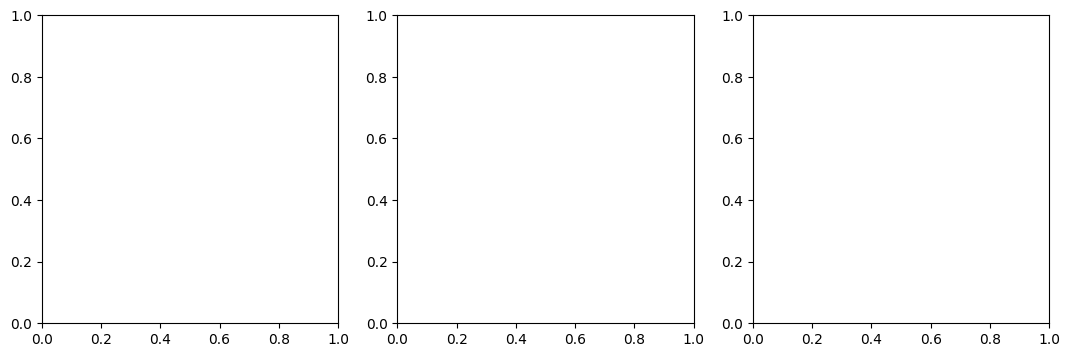

In [ ]:
from ultralytics.utils import patches
# 실전 2.5 라벨 시각화 검증 - 학습 전 반드시!
# 잘못 변환된 라벨로 학습하면 GPU를 몇 시간 태운다. 3장만 눈으로 확인
import glob, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image

_names = {"pothole", "crack"}
_imgs = sorted(glob.glob("yolo_dataset/images/train/*.jpg"))[:3]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, ip in zip(axes, _imgs):
    img = Image.open(ip)
    W, H = img.size
    ax.imshow(img)

    lp = ip.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"

    if os.path.exists(lp):
        for line in open(lp):
            cls, cx, cy, w, h = map(float, line.split())
            x1, y1 = (cx - w/2) * W, (cy - h/2) * H
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1), w * W, h * H,
                    fill=False, color="red", lw=2
                )
            )

In [ ]:
# 실전 3. YOLO 학습 - best.pt 를 만든다. (전이학습 + W&B 팀 로깅)
from ultralytics import YOLO, settings

# W&B 팀 설정
TEAM = "    "
PROJECT_NAME = "road-detect"
RUN_NAME = "kim_b16_e100" # 이름 규칙: 이름_데이터_에폭,  이름_배치_에폭

if TEAM:
  settings.update({"wandb": True}) # 실제 상황: YOLO와 W&B 로깅 ON
  project = f"{TEAM}/{PROJECT_NAME}"
  print(f"W&B 팀 로깅 ON - {project} / run={RUN_NAME}")

else:
  settings.update({"wandb": False}) # 팀 미설정 -> 끄고 로컬 저장
  project, RUN_NAME = "runs", "road_hazard"
  print("팀 미설정 -> 로컬 runs/에 저장")

model = YOLO("yolo11n.pt")
results = model.train(
    data="yolo_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20, # 조기 종료
    project=project, name=RUN_NAME, exist_ok=True,
    # YOLO는 내부에 코사인 스케줄러(lr) 기본 ON
)
print("\n 학습 완료 - best.pt", results.save_dir)

W&B 팀 로깅 ON -     /road-detect / run=kim_b16_e100
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kim_

wandb: Currently logged in as: gimm00999 (gimm00999-kwu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


RuntimeError: Dataset 'yolo_dataset/data.yaml' error ❌ Dataset 'yolo_dataset/data.yaml' images not found, missing path '/content/yolo_dataset/images/val'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
# 셀 1. results.csv - 에폭별 성적표 읽기
csv_candidates = glob.glob("**/coco8_test*/results.csv", recursive=True)
run_dir = os.path.dirname(sorted(csv_candidates)[-1])
print("결과 폴더:", run_dir)

IndexError: list index out of range

In [ ]:
# 셀 2. best.pt로 추론 - 우리가 만든 모델 사용하기
best_path = os.path.join(run_dir, "weights", "best.pt")
model = YOLO(best_path)

NameError: name 'run_dir' is not defined

In [ ]:
def show(r, title=""):
  plt.figure(figsize=(5, 6))
  plt.imshow(r.plot()[:, :, ::-1])  # r.plot()=  BGR -> RGB 로 뒤집기
  plt.axis("off")
  if title:
    plt.title(title)
  plt.show()

In [ ]:
r = model("crack2.png", verbose=False)[0]
name = [r.names[int(b.cls)] for b in r.boxes]
show(r, f"{name}  (감지 {len(r.boxes)}개)")

FileNotFoundError: crack2.png does not exist